In [8]:
import torch
import matplotlib.pyplot as plt
import os
import numpy as np
from utils.metrics import calculate_relative_loss

# FNO1d

In [2]:
fno1d_real_w_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-14_12-12-00/'
fno1d_numerical_w_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-14_12-39-09'
fno1d_finetuned_w_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-16_15-49-58/'

fno1d_real_w_sg_w_truth_data_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-16_15-51-17/'
fno1d_numerical_w_sg_w_truth_data_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-16_23-39-35/'
fno1d_finetuned_wsg_w_truth_data_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-19_19-08-29'

fno1d_real_wo_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-13_10-08-51/'
fno1d_numerical_wo_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-13_11-30-32'
fno1d_finetuned_wo_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-14_12-12-34/'

In [3]:
fno1d_real_w_sg_trajectories = torch.load(os.path.join(fno1d_real_w_sg_path, 'test_trajectories.pt'))
fno1d_numerical_w_sg_trajectories = torch.load(os.path.join(fno1d_numerical_w_sg_path, 'test_trajectories.pt'))
fno1d_finetuned_w_sg_trajectories = torch.load(os.path.join(fno1d_finetuned_w_sg_path, 'test_trajectories.pt'))

fno1d_real_w_sg_w_truth_data_trajectories = torch.load(os.path.join(fno1d_real_w_sg_w_truth_data_path, 'test_trajectories.pt'))
fno1d_numerical_w_sg_w_truth_data_trajectories = torch.load(os.path.join(fno1d_numerical_w_sg_w_truth_data_path, 'test_trajectories.pt'))
fno1d_finetuned_w_sg_w_truth_data_trajectories = torch.load(os.path.join(fno1d_finetuned_wsg_w_truth_data_path, 'test_trajectories.pt'))

fno1d_real_wo_sg_trajectories = torch.load(os.path.join(fno1d_real_wo_sg_path, 'test_trajectories.pt'))
fno1d_numerical_wo_sg_trajectories = torch.load(os.path.join(fno1d_numerical_wo_sg_path, 'test_trajectories.pt'))
fno1d_finetuned_wo_sg_trajectories = torch.load(os.path.join(fno1d_finetuned_wo_sg_path, 'test_trajectories.pt'))


## Plot error between autoregressive and ground truth trajectories

In [5]:
fno1d_real_w_sg_rel_error = calculate_relative_loss(fno1d_real_w_sg_trajectories['pred'] - fno1d_real_w_sg_trajectories['target'], fno1d_real_w_sg_trajectories['target'], reduction="mean")
fno1d_numerical_w_sg_rel_error = calculate_relative_loss(fno1d_numerical_w_sg_trajectories['pred'] - fno1d_numerical_w_sg_trajectories['target'], fno1d_numerical_w_sg_trajectories['target'], reduction="mean")
fno1d_finetuned_w_sg_rel_error = calculate_relative_loss(fno1d_finetuned_w_sg_trajectories['pred'] - fno1d_finetuned_w_sg_trajectories['target'], fno1d_finetuned_w_sg_trajectories['target'], reduction="mean")

fno1d_real_w_sg_w_truth_data_rel_error = calculate_relative_loss(fno1d_real_w_sg_w_truth_data_trajectories['pred'] - fno1d_real_w_sg_w_truth_data_trajectories['target'], fno1d_real_w_sg_w_truth_data_trajectories['target'], reduction="mean")
fno1d_numerical_w_sg_w_truth_data_rel_error = calculate_relative_loss(fno1d_numerical_w_sg_w_truth_data_trajectories['pred'] - fno1d_numerical_w_sg_w_truth_data_trajectories['target'], fno1d_numerical_w_sg_w_truth_data_trajectories['target'], reduction="mean")
fno1d_finetuned_w_sg_w_truth_data_rel_error = calculate_relative_loss(fno1d_finetuned_w_sg_w_truth_data_trajectories['pred'] - fno1d_finetuned_w_sg_w_truth_data_trajectories['target'], fno1d_finetuned_w_sg_w_truth_data_trajectories['target'], reduction="mean")

fno1d_real_wo_sg_rel_error = calculate_relative_loss(fno1d_real_wo_sg_trajectories['pred'] - fno1d_real_wo_sg_trajectories['target'], fno1d_real_wo_sg_trajectories['target'], reduction="mean")
fno1d_numerical_wo_sg_rel_error = calculate_relative_loss(fno1d_numerical_wo_sg_trajectories['pred'] - fno1d_numerical_wo_sg_trajectories['target'], fno1d_numerical_wo_sg_trajectories['target'], reduction="mean")
fno1d_finetuned_wo_sg_rel_error = calculate_relative_loss(fno1d_finetuned_wo_sg_trajectories['pred'] - fno1d_finetuned_wo_sg_trajectories['target'], fno1d_finetuned_wo_sg_trajectories['target'], reduction="mean")

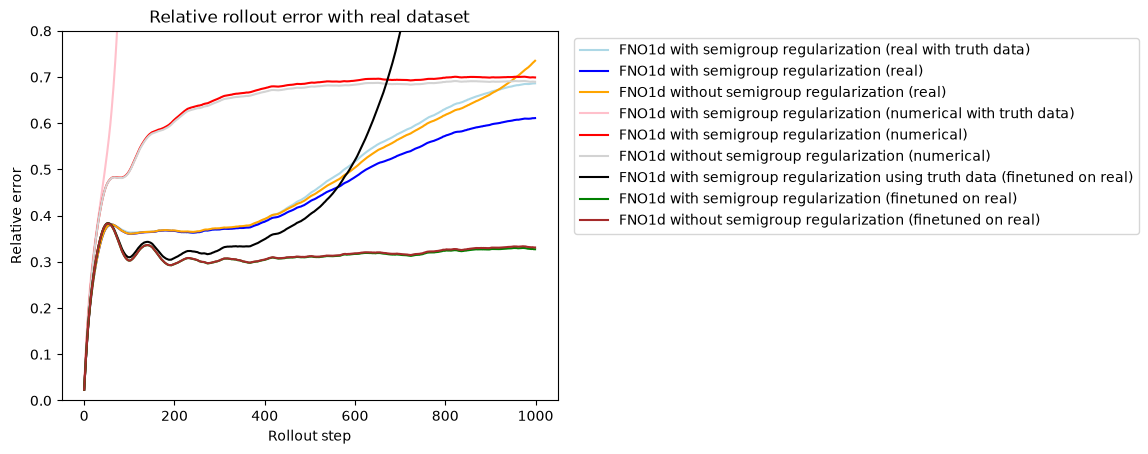

In [7]:
plt.plot(fno1d_real_w_sg_w_truth_data_rel_error, color="lightblue", label="FNO1d with semigroup regularization (real with truth data)")
plt.plot(fno1d_real_w_sg_rel_error, color="blue", label="FNO1d with semigroup regularization (real)")
plt.plot(fno1d_real_wo_sg_rel_error, color="orange", label="FNO1d without semigroup regularization (real)")

plt.plot(fno1d_numerical_w_sg_w_truth_data_rel_error, color="pink", label="FNO1d with semigroup regularization (numerical with truth data)")
plt.plot(fno1d_numerical_w_sg_rel_error, color="red", label="FNO1d with semigroup regularization (numerical)")
plt.plot(fno1d_numerical_wo_sg_rel_error, color="lightgray", label="FNO1d without semigroup regularization (numerical)")

plt.plot(fno1d_finetuned_w_sg_w_truth_data_rel_error, color="black", label="FNO1d with semigroup regularization using truth data (finetuned on real)")
plt.plot(fno1d_finetuned_w_sg_rel_error, color="green", label="FNO1d with semigroup regularization (finetuned on real)")
plt.plot(fno1d_finetuned_wo_sg_rel_error, color="brown", label="FNO1d without semigroup regularization (finetuned on real)")

plt.xlabel("Rollout step")
plt.ylabel("Relative error")
plt.ylim(0, 0.8)
#plt.yscale("log")
plt.title("Relative rollout error with real dataset")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

# DeepONet

In [ ]:
deeponet_real_w_sg_path = '/raid/work/sandbox/RealPDEBench/models/deeponet/deeponet_cylinder_eval/2026-07-19_19-58-57'
deeponet_numerical_w_sg_path = '/raid/work/sandbox/RealPDEBench/models/deeponet/deeponet_cylinder_eval/2026-07-19_19-59-16/'
#deeponet_finetuned_w_sg_path = '/raid/work/sandbox/RealPDEBench/models/deeponet/deeponet_cylinder_eval/2026-07-16_15-49-58/'

deeponet_real_w_sg_w_truth_data_path = '/raid/work/sandbox/RealPDEBench/models/deeponet/deeponet_cylinder_eval/2026-07-19_19-59-24/'
deeponet_numerical_w_sg_w_truth_data_path = '/raid/work/sandbox/RealPDEBench/models/deeponet/deeponet_cylinder_eval/2026-07-19_19-59-28/'
#deeponet_finetuned_wsg_w_truth_data_path = '/raid/work/sandbox/RealPDEBench/models/deeponet/deeponet_cylinder_eval/2026-07-19_19-08-29'

deeponet_real_wo_sg_path = '/raid/work/sandbox/RealPDEBench/models/deeponet/deeponet_cylinder_eval/2026-07-19_20-00-43/'
deeponet_numerical_wo_sg_path = '/raid/work/sandbox/RealPDEBench/models/deeponet/deeponet_cylinder_eval/2026-07-19_20-00-21/'
#deeponet_finetuned_wo_sg_path = '/raid/work/sandbox/RealPDEBench/models/deeponet/deeponet_cylinder_eval/2026-07-14_12-12-34/'

In [10]:
deeponet_real_w_sg_trajectories = torch.load(os.path.join(deeponet_real_w_sg_path, 'test_trajectories.pt'))
deeponet_numerical_w_sg_trajectories = torch.load(os.path.join(deeponet_numerical_w_sg_path, 'test_trajectories.pt'))
#deeponet_finetuned_w_sg_trajectories = torch.load(os.path.join(deeponet_finetuned_w_sg_path, 'test_trajectories.pt'))

deeponet_real_w_sg_w_truth_data_trajectories = torch.load(os.path.join(deeponet_real_w_sg_w_truth_data_path, 'test_trajectories.pt'))
deeponet_numerical_w_sg_w_truth_data_trajectories = torch.load(os.path.join(deeponet_numerical_w_sg_w_truth_data_path, 'test_trajectories.pt'))
#deeponet_finetuned_w_sg_w_truth_data_trajectories = torch.load(os.path.join(deeponet_finetuned_wsg_w_truth_data_path, 'test_trajectories.pt'))

deeponet_real_wo_sg_trajectories = torch.load(os.path.join(deeponet_real_wo_sg_path, 'test_trajectories.pt'))
deeponet_numerical_wo_sg_trajectories = torch.load(os.path.join(deeponet_numerical_wo_sg_path, 'test_trajectories.pt'))
#deeponet_finetuned_wo_sg_trajectories = torch.load(os.path.join(deeponet_finetuned_wo_sg_path, 'test_trajectories.pt'))


## Plot error between autoregressive and ground truth trajectories

In [11]:
deeponet_real_w_sg_rel_error = calculate_relative_loss(deeponet_real_w_sg_trajectories['pred'] - deeponet_real_w_sg_trajectories['target'], deeponet_real_w_sg_trajectories['target'], reduction="mean")
deeponet_numerical_w_sg_rel_error = calculate_relative_loss(deeponet_numerical_w_sg_trajectories['pred'] - deeponet_numerical_w_sg_trajectories['target'], deeponet_numerical_w_sg_trajectories['target'], reduction="mean")
#deeponet_finetuned_w_sg_rel_error = calculate_relative_loss(deeponet_finetuned_w_sg_trajectories['pred'] - deeponet_finetuned_w_sg_trajectories['target'], deeponet_finetuned_w_sg_trajectories['target'], reduction="mean")

deeponet_real_w_sg_w_truth_data_rel_error = calculate_relative_loss(deeponet_real_w_sg_w_truth_data_trajectories['pred'] - deeponet_real_w_sg_w_truth_data_trajectories['target'], deeponet_real_w_sg_w_truth_data_trajectories['target'], reduction="mean")
deeponet_numerical_w_sg_w_truth_data_rel_error = calculate_relative_loss(deeponet_numerical_w_sg_w_truth_data_trajectories['pred'] - deeponet_numerical_w_sg_w_truth_data_trajectories['target'], deeponet_numerical_w_sg_w_truth_data_trajectories['target'], reduction="mean")
#deeponet_finetuned_w_sg_w_truth_data_rel_error = calculate_relative_loss(deeponet_finetuned_w_sg_w_truth_data_trajectories['pred'] - deeponet_finetuned_w_sg_w_truth_data_trajectories['target'], deeponet_finetuned_w_sg_w_truth_data_trajectories['target'], reduction="mean")

deeponet_real_wo_sg_rel_error = calculate_relative_loss(deeponet_real_wo_sg_trajectories['pred'] - deeponet_real_wo_sg_trajectories['target'], deeponet_real_wo_sg_trajectories['target'], reduction="mean")
deeponet_numerical_wo_sg_rel_error = calculate_relative_loss(deeponet_numerical_wo_sg_trajectories['pred'] - deeponet_numerical_wo_sg_trajectories['target'], deeponet_numerical_wo_sg_trajectories['target'], reduction="mean")
#deeponet_finetuned_wo_sg_rel_error = calculate_relative_loss(deeponet_finetuned_wo_sg_trajectories['pred'] - deeponet_finetuned_wo_sg_trajectories['target'], deeponet_finetuned_wo_sg_trajectories['target'], reduction="mean")

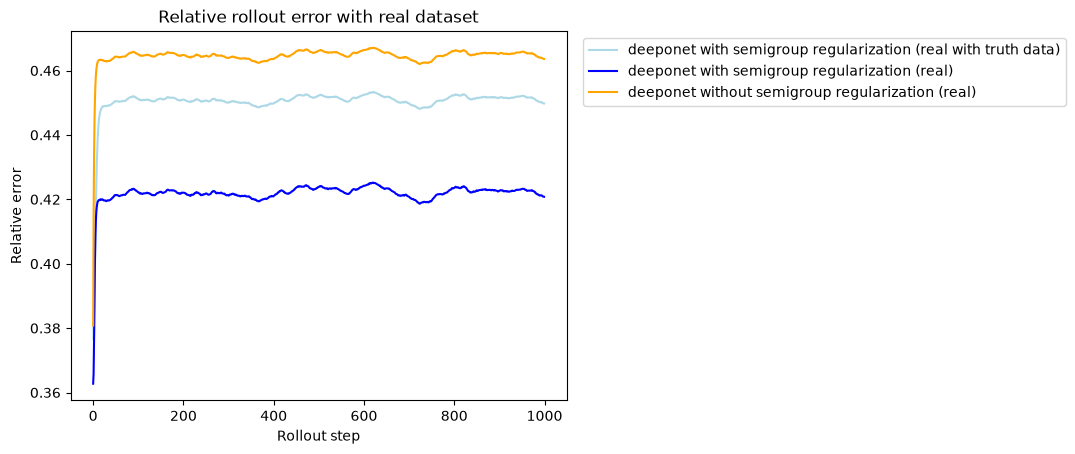

In [15]:
plt.plot(deeponet_real_w_sg_w_truth_data_rel_error, color="lightblue", label="deeponet with semigroup regularization (real with truth data)")
plt.plot(deeponet_real_w_sg_rel_error, color="blue", label="deeponet with semigroup regularization (real)")
plt.plot(deeponet_real_wo_sg_rel_error, color="orange", label="deeponet without semigroup regularization (real)")

#plt.plot(deeponet_numerical_w_sg_w_truth_data_rel_error, color="pink", label="deeponet with semigroup regularization (numerical with truth data)")
#plt.plot(deeponet_numerical_w_sg_rel_error, color="red", label="deeponet with semigroup regularization (numerical)")
#plt.plot(deeponet_numerical_wo_sg_rel_error, color="gray", label="deeponet without semigroup regularization (numerical)")

#plt.plot(deeponet_finetuned_w_sg_rel_error, color="green", label="deeponet with semigroup regularization (finetuned on real)")
#plt.plot(deeponet_finetuned_wo_sg_rel_error, color="brown", label="deeponet without semigroup regularization (finetuned on real)")
#plt.plot(deeponet_finetuned_w_sg_w_truth_data_rel_error, color="black", label="deeponet without semigroup regularization (finetuned on real)")

plt.xlabel("Rollout step")
plt.ylabel("Relative error")
#plt.ylim(0, 0.8)
#plt.yscale("log")
plt.title("Relative rollout error with real dataset")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))